## Setup

### Import modules

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.base import clone
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error

### Preprocessing

In [2]:
raw_name = "data.csv"
daily_name = "daily.csv"
weekly_name = "weekly.csv"
monthly_name ="monthly.csv"
results_name = "results.csv"
load_chunksize = 1_000_000

### Models

In [3]:
ts_splits = 5

hyperparams = {
    'adaboost': {
        'n_estimators':[100,300,500,800,1500],
        'learning_rate':[0.01,0.03,0.05,0.08],
    },
    'xgboost': {
        'n_estimators':[100,300,500,800,1500],
        'learning_rate':[0.01,0.03,0.05,0.08],
        'max_depth':[2,3,5,8],
        'subsample':[0.6,0.8,1],
        'gamma':[0,0.1,0.25,0.5]
    }
}

sample_size = 25

### Auxiliary values

In [4]:
def add_lag_features(df, target_col, lags):
    df = df.sort_values("date").copy()
    
    for lag in lags:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)
    
    return df

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

try:
    results = pd.read_csv(results_name)
    need_results = False
except:
    need_results = True

print('Setup complete!')

Setup complete!


## Preprocessing

### Daily aggregation

In [5]:
if need_results:
    try:
        daily = pd.read_csv(daily_name)
        print('Daily aggregation loaded!')
    except:
        results = []

        for chunk in pd.read_csv(raw_name, chunksize=load_chunksize):

            chunk = chunk.dropna(subset=["onpromotion"])
            chunk["onpromotion"] = chunk["onpromotion"].astype(int)

            # weighted promotion = sales * promotion
            chunk["promo_weight"] = chunk["unit_sales"] * chunk["onpromotion"]

            grouped = chunk.groupby("date").agg(
                sales=("unit_sales", "sum"),
                promo_weight=("promo_weight", "sum")
            ).reset_index()

            results.append(grouped)

        print('Dataset loaded!')

        daily = pd.concat(results)
        # aggregate across chunks
        daily = daily.groupby("date").agg(
            sales=("sales", "sum"),
            promo_weight=("promo_weight", "sum")
        ).reset_index()
        daily["promotion"] = daily["promo_weight"] / daily["sales"].replace(0, pd.NA)

        daily = daily[["date", "sales", "promotion"]]
        daily["date"] = pd.to_datetime(daily["date"])
        daily["day_of_week"] = daily["date"].dt.dayofweek
        daily["month"] = daily["date"].dt.month
        daily["year"] = daily["date"].dt.year

        daily = add_lag_features(
            daily,
            target_col="sales",
            lags=[1, 7, 14, 28]
        )
        daily = daily.dropna()

        daily.to_csv(daily_name, index=False)
        print('Daily aggregation saved!')

C:\Users\csg12\AppData\Local\Temp\ipykernel_10532\97411735.py:8: DtypeWarning: Columns (0: onpromotion) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(raw_name, chunksize=load_chunksize):


Dataset loaded!
Daily aggregation saved!


### Weekly aggregation

In [6]:
if need_results:
    try:
        weekly = pd.read_csv(weekly_name)
        print('Weekly aggregation loaded!')
    except:
        weekly = daily.copy()

        # Reconstruct promo_weight to avoid averaging ratios
        weekly["promo_weight"] = weekly["promotion"] * weekly["sales"]

        weekly = weekly.groupby(pd.Grouper(key="date", freq="W")).agg(
            sales=("sales", "sum"),
            promo_weight=("promo_weight", "sum")
        ).reset_index()

        weekly["promotion"] = weekly["promo_weight"] / weekly["sales"]

        weekly = weekly[["date", "sales", "promotion"]]
        weekly["month"] = weekly["date"].dt.month
        weekly["year"] = weekly["date"].dt.year

        weekly = add_lag_features(
            weekly,
            target_col="sales",
            lags=[1, 2, 4, 8]
        )
        weekly = weekly.dropna()

        weekly.to_csv(weekly_name, index=False)
        print('Weekly aggregation saved!')

Weekly aggregation saved!


### Monthly aggregation

In [7]:
if need_results:
    try:
        monthly = pd.read_csv(monthly_name)
        print('Monthly aggregation loaded!')
    except:
        monthly = daily.copy()

        monthly["promo_weight"] = monthly["promotion"] * monthly["sales"]

        monthly = monthly.groupby(pd.Grouper(key="date", freq="ME")).agg(
            sales=("sales", "sum"),
            promo_weight=("promo_weight", "sum")
        ).reset_index()

        monthly["promotion"] = monthly["promo_weight"] / monthly["sales"]

        monthly = monthly[["date", "sales", "promotion"]]
        monthly["month"] = monthly["date"].dt.month
        monthly["year"] = monthly["date"].dt.year

        monthly = add_lag_features(
            monthly,
            target_col="sales",
            lags=[1, 2, 3, 6]
        )
        monthly = monthly.dropna()

        monthly.to_csv(monthly_name, index=False)
        print('Monthly aggregation saved!')

        print('Data ready!')

Monthly aggregation saved!
Data ready!


### Models

### Data setup

In [8]:
if need_results:
    daily_split_id = int(len(daily) * 0.8)
    daily_train = daily.iloc[:daily_split_id]
    daily_test  = daily.iloc[daily_split_id:]
    weekly_split_id = int(len(weekly) * 0.8)
    weekly_train = weekly.iloc[:weekly_split_id]
    weekly_test  = weekly.iloc[weekly_split_id:]
    monthly_split_id = int(len(monthly) * 0.8)
    monthly_train = monthly.iloc[:monthly_split_id]
    monthly_test  = monthly.iloc[monthly_split_id:]
    train = {
        'daily': daily_train,
        'weekly': weekly_train,
        'monthly': monthly_train
    }
    test = {
        'daily': daily_test,
        'weekly': weekly_test,
        'monthly': monthly_test
    }

### Parameter tuning

In [9]:
if need_results:
    best_models = []

    # time-series cross validation
    tscv = TimeSeriesSplit(n_splits=ts_splits)

    for dataset_name, df in train.items():

        print(f"\n===== Processing {dataset_name} dataset =====")

        # features and target
        X = df.drop(columns=['date', 'sales'])
        y = df['sales']

        # -----------------------------
        # AdaBoost
        # -----------------------------
        print(f"Running AdaBoost GridSearchCV for {dataset_name}...")

        ada_model = AdaBoostRegressor()

        ada_search = GridSearchCV(
            estimator=ada_model,
            param_grid=hyperparams['adaboost'],
            cv=tscv,
            scoring='neg_mean_absolute_error',
            n_jobs=-1,
            verbose=1
        )

        ada_search.fit(X, y)

        best_ada = ada_search.best_estimator_

        best_models.append({
            'dataset': dataset_name,
            'model_name': 'AdaBoost',
            'best_model': best_ada,
            'best_params': ada_search.best_params_,
            'best_score': -ada_search.best_score_
        })

        print("Best AdaBoost params:", ada_search.best_params_)
        print("Best AdaBoost MAE:", -ada_search.best_score_)

        # -----------------------------
        # XGBoost
        # -----------------------------
        print(f"\nRunning XGBoost GridSearchCV for {dataset_name}...")

        xgb_model = XGBRegressor(objective='reg:squarederror')

        xgb_search = GridSearchCV(
            estimator=xgb_model,
            param_grid=hyperparams['xgboost'],
            cv=tscv,
            scoring='neg_mean_absolute_error',
            n_jobs=-1,
            verbose=1
        )

        xgb_search.fit(X, y)

        best_xgb = xgb_search.best_estimator_

        best_models.append({
            'dataset': dataset_name,
            'model_name': 'XGBoost',
            'best_model': best_xgb,
            'best_params': xgb_search.best_params_,
            'best_score': -xgb_search.best_score_
        })

        print("Best XGBoost params:", xgb_search.best_params_)
        print("Best XGBoost MAE:", -xgb_search.best_score_)

    print("\nHyperparameter tuning complete!")
    print(f"Stored {len(best_models)} best models.")


===== Processing daily dataset =====
Running AdaBoost GridSearchCV for daily...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best AdaBoost params: {'learning_rate': 0.01, 'n_estimators': 100}
Best AdaBoost MAE: 81987.66848045193

Running XGBoost GridSearchCV for daily...
Fitting 5 folds for each of 960 candidates, totalling 4800 fits
Best XGBoost params: {'gamma': 0, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
Best XGBoost MAE: 72669.31263081249

===== Processing weekly dataset =====
Running AdaBoost GridSearchCV for weekly...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best AdaBoost params: {'learning_rate': 0.01, 'n_estimators': 100}
Best AdaBoost MAE: 486678.7204318512

Running XGBoost GridSearchCV for weekly...
Fitting 5 folds for each of 960 candidates, totalling 4800 fits
Best XGBoost params: {'gamma': 0, 'learning_rate': 0.08, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best XGBoost MAE: 430014.3332

### Training and evaluation

In [10]:
if need_results:
    tscv = TimeSeriesSplit(n_splits=sample_size)

    results = []

    for model_info in best_models:
        dataset_name = model_info['dataset']
        model_name = model_info['model_name']
        model = model_info['best_model']

        data = train[dataset_name]
        X = data.drop(columns=['date', 'sales'])
        y = data['sales']

        rmse_scores = []
        mae_scores = []
        mape_scores = []

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            mae = mean_absolute_error(y_val, y_pred)
            mape = mean_absolute_percentage_error(y_val, y_pred)

            rmse_scores.append(rmse)
            mae_scores.append(mae)
            mape_scores.append(mape)

        results.append({
            'dataset': dataset_name,
            'model_name': model_name,
            'rmse_scores': rmse_scores,
            'mae_scores': mae_scores,
            'mape_scores': mape_scores,
            'rmse_mean': np.mean(rmse_scores),
            'mae_mean': np.mean(mae_scores),
            'mape_mean': np.mean(mape_scores),
            'rmse_std': np.std(rmse_scores),
            'mae_std': np.std(mae_scores),
            'mape_std': np.std(mape_scores),
        })

    results = pd.DataFrame(results)
    results.to_csv(results_name)
    print('Results saved!')

Results saved!


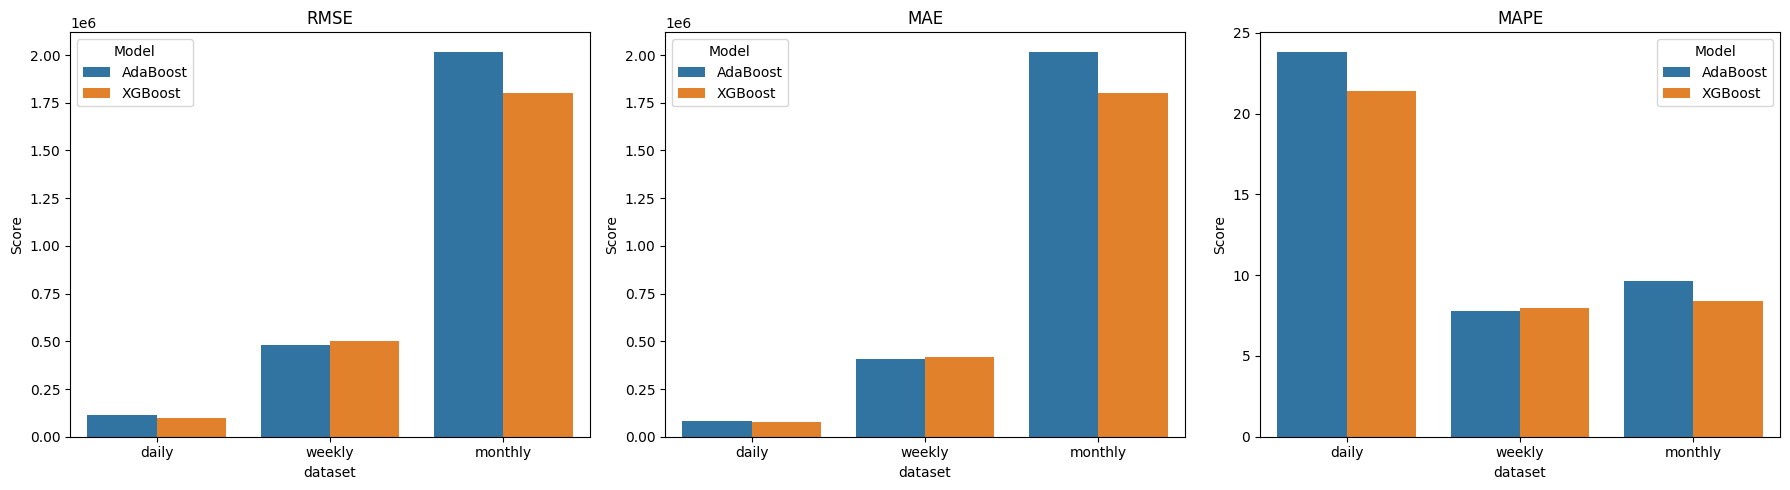

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['rmse', 'mae', 'mape']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    sns.barplot(
        data=results,
        x='dataset',
        y=f'{metric}_mean',
        hue='model_name',
        ax=ax,
        capsize=0.1
    )
    '''
    # add error bars manually (since seaborn barplot doesn't fully expose std cleanly in all versions)
    for j, bar in enumerate(ax.patches):
        dataset_idx = j // len(results['model_name'].unique())
        model_idx = j % len(results['model_name'].unique())
    '''
        
    ax.set_title(metric.upper())
    ax.set_ylabel('Score')
    ax.legend(title='Model')

plt.tight_layout()
plt.show()